In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your soil dataset (replace 'soil_data.csv' with your exact filename)
df = pd.read_csv('soil_data.csv')

# View the first 5 rows and column structures
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8000, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


/tmp/ipykernel_14054/3058735854.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Soil Type', palette='viridis')
/tmp/ipykernel_14054/3058735854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fertilizer Name', palette='rocket')


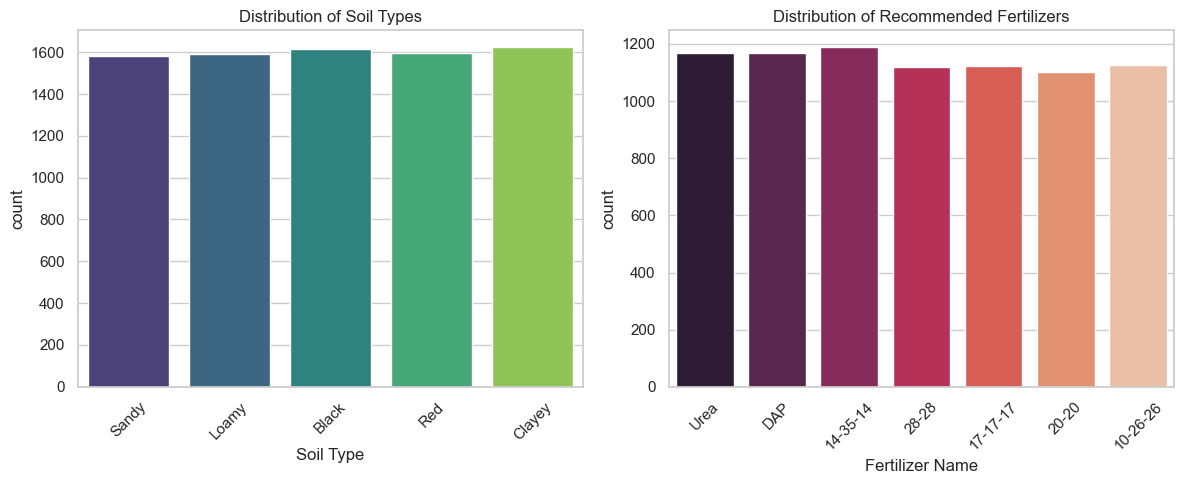

In [3]:
# Set up the plotting grid styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Count of Soil Types
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Soil Type', palette='viridis')
plt.title('Distribution of Soil Types')
plt.xticks(rotation=45)

# Plot 2: Count of Recommended Fertilizers
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Fertilizer Name', palette='rocket')
plt.title('Distribution of Recommended Fertilizers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


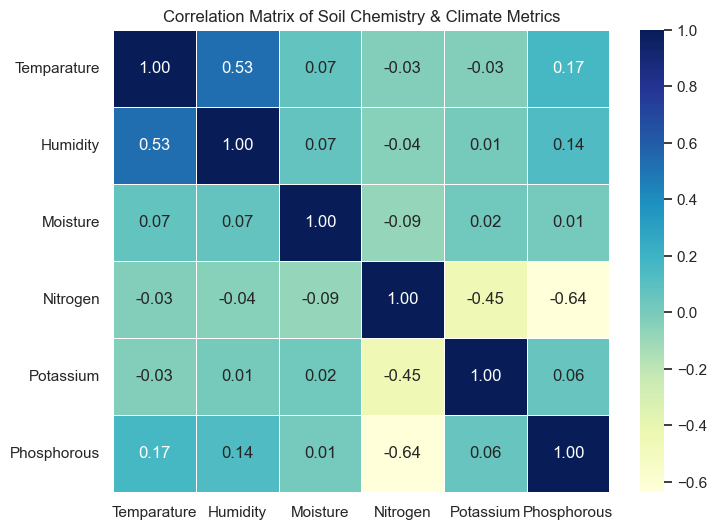

In [4]:
plt.figure(figsize=(8, 6))

# Select only numerical columns for correlation profiling
numerical_cols = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Soil Chemistry & Climate Metrics')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf

# 1. Load your CSV dataset
df = pd.read_csv('soil_data.csv')

# 2. Separate your Input Features (X) and Target Label (y)
# Let's assume we are predicting 'Fertilizer Name'
X = df.drop(columns=['Fertilizer Name'])
y = df['Fertilizer Name']

# 3. Convert Categorical Text columns in X into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Soil Type', 'Crop Type'], drop_first=False)

# 4. Encode the output target labels (e.g., Urea -> 0, NPK -> 1, etc.)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 6. Scale numerical values uniformly (avoids columns with large numbers dominating the weights)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features shape after encoding:", X_train_scaled.shape)
print("Unique target classes to predict:", len(np.unique(y_encoded)))

I0000 00:00:1780031635.936969   14054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780031635.942081   14054 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780031636.492102   14054 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780031637.894803   14054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Features shape after encoding: (6400, 22)
Unique target classes to predict: 7


In [6]:
from tensorflow.keras import models, layers

# Calculate the input dimensions and total output labels automatically
input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_encoded))

# Build a fully-connected Artificial Neural Network
ann_model = models.Sequential([
    # Input Layer + First Hidden Layer
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.2), # Prevents overfitting
    
    # Second Hidden Layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    # Output Layer (Softmax outputs probabilities across your target fertilizers/crops)
    layers.Dense(num_classes, activation='softmax')
])

# Compile the Network
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/home/karan/Coding/Flutter_Project/agrismart/backend/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1780031638.314577   14054 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,783 (14.78 KB)

 Trainable params: 3,783 (14.78 KB)

 Non-trainable params: 0 (0.00 B)